# Chapter 5 Solutions: Quantum Gates

---

**📘 INSTRUCTOR NOTE:**
- Solutions use the same utilities as the main textbook notebooks
- Students should work through the main chapter notebook first
- Some solutions may still be in development (marked as WIP)

---


In [2]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

# Import shared utilities (same as main notebooks)
from Chapter08_QuantumGates_functions import simulate_measurements #type: ignore

print('Solutions setup complete!')

Solutions setup complete!


## 5.1 Single Qubit Operators

### Universal Operator

In [3]:

j = np.emath.sqrt(-1) # type: ignore

def UniversalOperator(theta,phi,lambdaAngle):
	U = np.array([[np.cos(theta/2),-np.exp(1j*lambdaAngle)*np.sin(theta/2)],
			      [np.exp(1j*phi)*np.sin(theta/2), np.exp(1j*(phi+lambdaAngle))*np.cos(theta/2)]])
	return U
U = UniversalOperator(np.pi/2,np.pi/2,np.pi/2)
print(U)


[[ 7.07106781e-01+0.00000000e+00j -4.32978028e-17-7.07106781e-01j]
 [ 4.32978028e-17+7.07106781e-01j -7.07106781e-01+8.65956056e-17j]]


### Product of Operators

In [ ]:
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])

U1 =np.matmul(X,Z)
print(U1)

U2 =np.matmul(Z,X)
print(U2)

### RX Operator

In [ ]:
from matplotlib import pyplot as plt

circuit = QuantumCircuit(1, 1)  # type: ignore
circuit.rx(np.pi/3,0) # apply Rx to qubit 0
#  measure and place result in classical bit
circuit.measure(0, 0) 

shots = []
errors= []
nAttempts= 10
for i in range(4):
	nShots= 100*(10**i)
	err = 0
	for k in range(nAttempts):
		counts = simulateCircuit(circuit,nShots) # type: ignore
		P0 = counts['0']/nShots
		err = err + np.abs(P0-0.75)
	err = err/nAttempts
	shots.append(nShots)
	errors.append(err)
plt.loglog(shots, errors) 
plt.grid(True)

plt.xlabel('nShots', fontsize=16)
plt.ylabel(r'$\varepsilon$', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(ticks = [1e-1,1e-2,1e-3],fontsize=16)

### State Preparation using RX

Counts: {'0': 765, '1': 235}


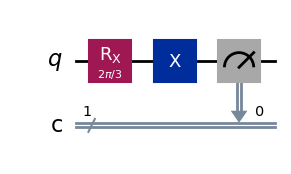

In [5]:
circuit = QuantumCircuit(1, 1)   # type: ignore
theta = 2*np.pi/3
circuit.rx(theta,0)
circuit.x(0) 
circuit.measure(0, 0) 
counts = simulate_measurements(circuit,1000)# type: ignore
print('Counts:',counts)
circuit.draw('mpl') 


### State Preparation 2

In [ ]:
circuit = QuantumCircuit(1, 1)  # type: ignore
theta =  2*np.arctan2(np.sqrt(3)/4,1/2)
circuit.rx(theta,0)
circuit.ry(np.pi/3,0)
circuit.measure(0, 0) 
counts = simulateCircuit(circuit,1000) # type: ignore
print('Counts:',counts)
circuit.draw('mpl') 


### HTSH Circuit

In [ ]:
circuit = QuantumCircuit(1, 1)  # type: ignore
circuit.h(0)
circuit.t(0)
circuit.s(0)
circuit.h(0)
circuit.measure(0, 0) 
counts = simulateCircuit(circuit,10000) # type: ignore
print('Counts:',counts)
circuit.draw('mpl') 

### Double Hadamard

In [ ]:
circuit = QuantumCircuit(1, 1)  # type: ignore
circuit.h(0)
circuit.h(0) 
circuit.measure(0, 0)
counts = simulateCircuit(circuit,1000) # type: ignore
print('Counts:',counts)
circuit.draw('mpl') 

### Double XYZ

In [ ]:
circuit = QuantumCircuit(1, 1)  # type: ignore
circuit.x(0)
circuit.y(0)
circuit.z(0) 
circuit.measure(0, 0) 
counts = simulateCircuit(circuit,1000) # type: ignore
print('Counts:',counts)
circuit.draw('mpl') 


### XYZ

In [ ]:
circuit = QuantumCircuit(1, 1)# type: ignore  
circuit.z(0)
circuit.y(0)
circuit.x(0) 
circuit.measure(0, 0) 
counts = simulateCircuit(circuit,1000) # type: ignore
print('Counts:',counts)
circuit.draw('mpl') 

### HSTH Circuit

In [ ]:
circuit = QuantumCircuit(1, 1)  # type: ignore
circuit.h(0)
circuit.t(0)
circuit.s(0) 
circuit.h(0)
circuit.measure(0, 0) 
counts = simulateCircuit(circuit,10000)# type: ignore
print('Counts:',counts)
circuit.draw('mpl') 